In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/delivery_data.csv")

In [2]:
df["trip_creation_time"] = pd.to_datetime(
    df["trip_creation_time"]
)

df["hour"] = df["trip_creation_time"].dt.hour

df["day_of_week"] = (
    df["trip_creation_time"]
    .dt.dayofweek
)

In [3]:
df["delay_ratio"] = (
    df["actual_time"] /
    df["osrm_time"]
)

df["segment_delay_ratio"] = (
    df["segment_actual_time"] /
    df["segment_osrm_time"]
)

In [4]:
import networkx as nx

corridor_df = (
    df.groupby(
        ["source_center", "destination_center"]
    )["delay_ratio"]
    .median()
    .reset_index()
)

G = nx.from_pandas_edgelist(
    corridor_df,
    source="source_center",
    target="destination_center",
    edge_attr="delay_ratio",
    create_using=nx.DiGraph()
)

betweenness = nx.betweenness_centrality(G)

In [5]:
df["source_centrality"] = (
    df["source_center"]
    .map(betweenness)
)

df["destination_centrality"] = (
    df["destination_center"]
    .map(betweenness)
)

In [6]:
features = [
    "osrm_time",
    "osrm_distance",
    "actual_distance_to_destination",
    "hour",
    "day_of_week",
    "source_centrality",
    "destination_centrality",
    "segment_osrm_time",
    "segment_osrm_distance"
]

In [8]:
X = df[features]

y = df["actual_time"]

X = X.fillna(0)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [10]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [11]:
preds = model.predict(X_test)

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 32.582515257105925
RMSE: 67.29206722592876
R2: 0.9873514034252651


In [13]:
within_15 = (
    abs(preds - y_test) / y_test
) <= 0.15

accuracy_15 = within_15.mean()

print(
    "Predictions within 15%:",
    accuracy_15
)

Predictions within 15%: 0.5893559743218058


In [14]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

importance_df

,feature,importance
1,osrm_distance,0.887085
2,actual_distance_to_destination,0.091318
0,osrm_time,0.006264
5,source_centrality,0.004957
6,destination_centrality,0.003682
3,hour,0.002323
4,day_of_week,0.002190
8,segment_osrm_distance,0.001101
7,segment_osrm_time,0.001079


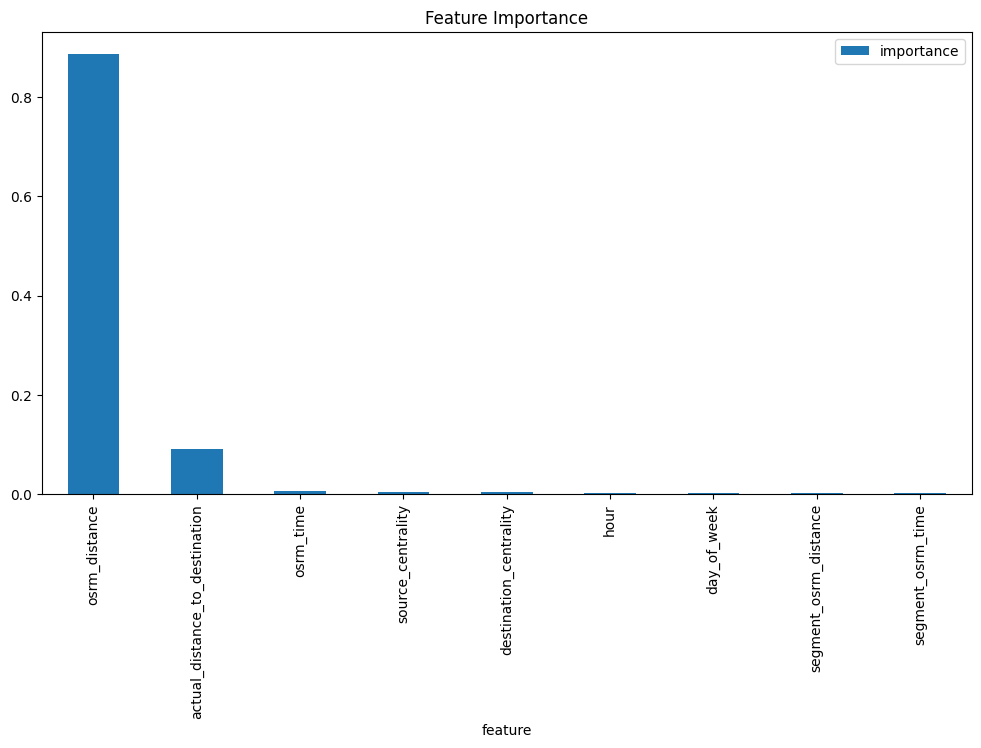

In [17]:
import matplotlib.pyplot as plt

importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(12,6)
)

plt.title("Feature Importance")
plt.show()